In [1]:
import joblib
import numpy as np
import pandas as pd
from PIL import Image


# case = "A50"
# slide = "WSA_LngSP9258467"
case = "A37"
slide = "WSA_LngSP9258464"
# case = "A42"
# slide = "WSA_LngSP8759311"


# JPG图像的路径
jpg_path = '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/'+slide+'/'+slide+'_low_res.jpg'
# 加载图像
img = Image.open(jpg_path)

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]
# selected_cell_names = ['Ciliated', 'Basal', 'AT1', 'AT2', 'Chondrocyte', 'T_reg', 'Suprabasal', 'SMG_Mucous', 'Fibro_adventitial', 'Fibro_peribronchial', 'B_naive', 'B_plasma_IgA']
selected_cell_names = ['B_plasma_IgA']
# selected_cell_names = ['Ciliated', 'Basal', 'SMG_Serous', 'Chondrocyte', 'Fibro_adventitial', 'B_plasma_IgA']
# selected_cell_names = ['CD4_EM_Effector', 'B_naive', 'B_plasmablast', 'B_plasma_IgA']

In [2]:
cell_names

['AT1',
 'AT2',
 'B_memory',
 'B_naive',
 'B_plasma_IgA',
 'B_plasma_IgG',
 'B_plasmablast',
 'Basal',
 'CD4_EM_Effector',
 'CD4_TRM',
 'CD4_naive_CM',
 'CD8_EM',
 'CD8_EM_EMRA',
 'CD8_TRM_EM',
 'CD8_TRM',
 'Chondrocyte',
 'Ciliated',
 'DC_1',
 'DC_2',
 'DC_activated',
 'DC_plasmacytoid',
 'Deuterosomal',
 'Dividing_AT2',
 'Dividing_Basal',
 'Endothelia_Lymphatic',
 'Endothelia_vascular_Cap_a',
 'Endothelia_vascular_Cap_g',
 'Endothelia_vascular_arterial_pulmonary',
 'Endothelia_vascular_arterial_systemic',
 'Endothelia_vascular_venous_pulmonary',
 'Endothelia_vascular_venous_systemic',
 'Erythrocyte',
 'Fibro_adventitial',
 'Fibro_alveolar',
 'Fibro_immune_recruiting',
 'Fibro_myofibroblast',
 'Fibro_peribronchial',
 'Fibro_perichondrial',
 'ILC',
 'Ionocyte_n_Brush',
 'MAIT',
 'Macro_CHIT1',
 'Macro_interstitial',
 'Macro_AW_CX3CR1',
 'Macro_alveolar_metallothioneins',
 'Macro_alv',
 'Macro_dividing',
 'Macro_int',
 'Macro_CCL',
 'Mast_cell',
 'Megakaryocyte',
 'Mesothelia',
 'Macrop

In [4]:
import matplotlib.pyplot as plt


def plot_cell_abundance(img, X, Y, cell_abundance, slide, model, dir_path, cell_name, cmap='viridis'):
    # 创建图形和轴对象
    fig, ax = plt.subplots()

    # 水平和垂直翻转图像
    ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT))

    # 水平和垂直翻转散点图的坐标
    # 'ro'表示红色圆点
    # sc = ax.scatter(img.size[0] - (X), img.size[1] - (Y),
    #                 c=cell_abundance,
    #                 s=95, alpha=0.80, cmap=cmap)
    sc = ax.scatter(img.size[0] - (X), img.size[1] - (Y),
                c=cell_abundance,
                s=9, alpha=0.80, cmap=cmap)

    # 设置x轴和y轴的界限
    ax.set_xlim(img.size[0] - (min(X)-50), img.size[0] - (max(X)+50))
    ax.set_ylim(img.size[1] - (min(Y)-50), img.size[1] - (max(Y)+50))

    # 翻转坐标轴
    ax.set_ylim(ax.get_ylim()[::-1])

    # 关闭坐标轴
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

    # 添加color bar
    cbar = plt.colorbar(sc, ax=ax)

    # 设置 color bar 的刻度字体大小
    cbar.ax.tick_params(labelsize=14)  # 将字体大小设置为 1

    # ax.set_title(slide, fontsize=16)

    # 保存图
    plt.savefig(dir_path + '/' + slide  + '_' + cell_name + '_' + model + '.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
    plt.savefig(dir_path + '/' + slide  + '_' + cell_name + '_' + model + '.svg', format='svg', bbox_inches='tight', pad_inches=0)
    # plt.show()

In [5]:
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
hist2cell_abundances = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
cell2loction_abundances = np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0] / 4
Y = coordinates[:, 1] / 4

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
stnet_abundances = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)

/tmp/ipykernel_3799325/742070216.py:9: DeprecationWarning: FLIP_TOP_BOTTOM is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_TOP_BOTTOM instead.
  ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT))
/tmp/ipykernel_3799325/742070216.py:9: DeprecationWarning: FLIP_LEFT_RIGHT is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_LEFT_RIGHT instead.
  ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT))
/tmp/ipykernel_3799325/742070216.py:9: DeprecationWarning: FLIP_TOP_BOTTOM is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_TOP_BOTTOM instead.
  ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT))
/tmp/ipykernel_3799325/742070216.py:9: DeprecationWarning: FLIP_LEFT_RIGHT is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_LEFT_RIGHT instead.
  ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).tr

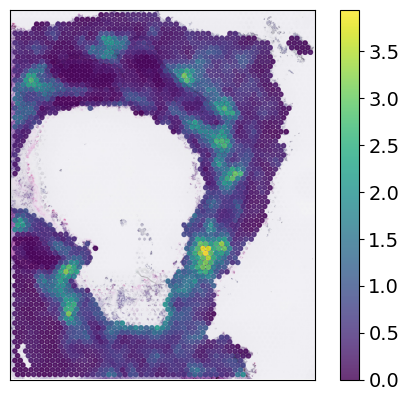

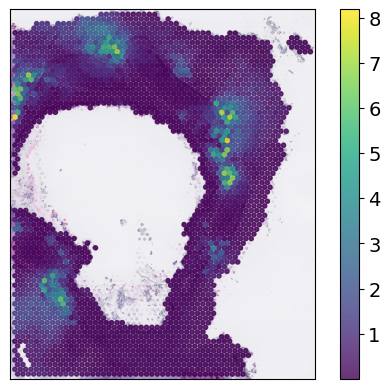

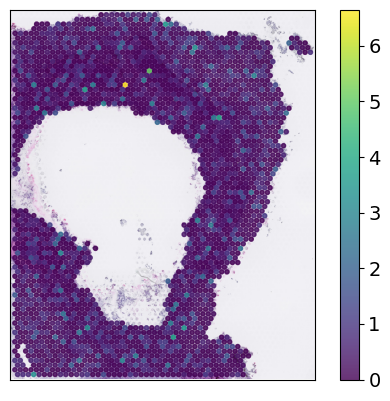

In [6]:
for i in range(len(cell_names)):
    if cell_names[i] in selected_cell_names:
        plot_cell_abundance(img, X, Y, hist2cell_abundances[:, i], slide, 'Hist2Cell', '/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung/cell_abundance_paper_figures', cell_names[i], cmap='viridis')
        plot_cell_abundance(img, X, Y, cell2loction_abundances[:, i], slide, 'Cell2Location', '/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung/cell_abundance_paper_figures', cell_names[i], cmap='viridis')
        plot_cell_abundance(img, X, Y, stnet_abundances[:, i], slide, 'STNet', '/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung/cell_abundance_paper_figures', cell_names[i], cmap='viridis')